# Image Captioning with PyTorch: ResNet Encoder + Attention Decoder

This notebook trains and evaluates an image captioning model on Flickr8k.
Model definitions and utilities live in `models.py` and `utils.py`;
paths and W&B settings are in `global_config.py`.

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))

import pickle
import random
from collections import defaultdict
from datetime import datetime
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet50_Weights

import global_config as gc
from models import (
    DecoderRNNWithAttention,
    EncoderCNN,
    Flickr8kCaptionDataset,
    Vocabulary,
    make_collate_fn,
)
from utils import (
    clean_caption,
    clean_reference_caption,
    device_check,
    evaluate_bleu,
    generate_caption_beam_search,
    generate_caption_greedy,
    load_captions_file,
    show_image_with_captions,
    train_captioning,
)

In [2]:
LOG_WANDB = True

# Reproducibility settings.
SEED = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = device_check()

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    PIN_MEMORY = True
    NUM_WORKERS = 16
    PERSISTENT_WORKERS = True
    PREFETCH_FACTOR = 4
else:
    PIN_MEMORY = False
    NUM_WORKERS = 0
    PERSISTENT_WORKERS = False
    PREFETCH_FACTOR = 2

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
Python version: 3.11.15 (main, Mar  3 2026, 09:26:23) [GCC 11.4.0]
OS: Linux 5.15.0-164-generic
Device: cuda
GPU name: NVIDIA GeForce RTX 2080 Ti
CUDA version used by PyTorch: 13.0


In [3]:
gc.DATA_DIR.mkdir(parents=True, exist_ok=True)
gc.IMAGE_DIR.mkdir(parents=True, exist_ok=True)
assert gc.CAPTIONS_FILE.exists(), (
    f"Captions file not found: {gc.CAPTIONS_FILE}"
)

# Create a timestamped run directory.
RUN_NAME = "resnet_attention_" + datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = gc.RUNS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=False)

print("Run directory:", RUN_DIR.resolve())

Run directory: /root/D7047E/Lab3/runs/resnet_attention_20260506_132752


## Loading and cleaning captions

Each image in Flickr8k has multiple reference captions.
We lowercase, strip punctuation, and add `<start>` / `<end>` tokens.

In [4]:
captions_df = load_captions_file(gc.CAPTIONS_FILE)
captions_df["clean_caption"] = captions_df["caption"].apply(
    clean_caption
)

print("Number of caption rows:", len(captions_df))
print("Number of unique images:", captions_df["image"].nunique())

# Build image-to-captions dict; ignore missing image files.
image_to_captions = defaultdict(list)

for _, row in captions_df.iterrows():
    image_name = row["image"]
    image_path = gc.IMAGE_DIR / image_name

    if image_path.exists():
        image_to_captions[image_name].append(row["clean_caption"])

image_to_captions = dict(image_to_captions)
all_image_names = sorted(list(image_to_captions.keys()))

print("Images with valid captions:", len(all_image_names))

sample_image = all_image_names[0]
print("Sample image:", sample_image)
print("Sample captions:")
for caption in image_to_captions[sample_image]:
    print("-", caption)

Number of caption rows: 40455
Number of unique images: 8091
Images with valid captions: 8091
Sample image: 1000268201_693b08cb0e.jpg
Sample captions:
- <start> child in pink dress is climbing up set of stairs in an entry way <end>
- <start> girl going into wooden building <end>
- <start> little girl climbing into wooden playhouse <end>
- <start> little girl climbing the stairs to her playhouse <end>
- <start> little girl in pink dress going into wooden cabin <end>


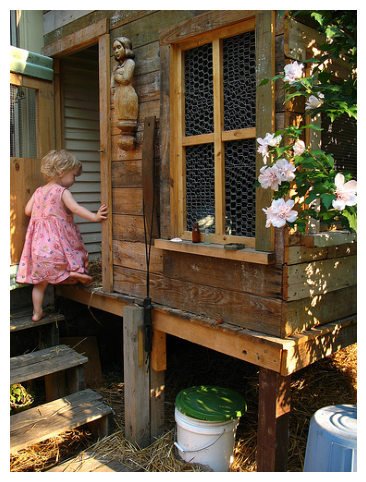

Reference captions:
- <start> child in pink dress is climbing up set of stairs in an entry way <end>
- <start> girl going into wooden building <end>
- <start> little girl climbing into wooden playhouse <end>
- <start> little girl climbing the stairs to her playhouse <end>
- <start> little girl in pink dress going into wooden cabin <end>


In [5]:
show_image_with_captions(sample_image, image_to_captions, gc.IMAGE_DIR)

## Train, validation, and test split

The dataset is split by image filename, not by caption row,
to prevent data leakage between splits.

In [6]:
# Split by image names.
train_images, temp_images = train_test_split(
    all_image_names,
    test_size=0.20,
    random_state=SEED,
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=SEED,
)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Train images: 6472
Validation images: 809
Test images: 810


## Vocabulary

The vocabulary is built only from training captions.
Special tokens: `<pad>`, `<unk>`, `<start>`, `<end>`.
Words appearing fewer than `min_freq=5` times are excluded.

In [7]:
train_captions = []
for image_name in train_images:
    train_captions.extend(image_to_captions[image_name])

vocab = Vocabulary(min_freq=5)
vocab.build(train_captions)

pad_idx = vocab.word2idx[vocab.pad_token]
unk_idx = vocab.word2idx[vocab.unk_token]
start_idx = vocab.word2idx[vocab.start_token]
end_idx = vocab.word2idx[vocab.end_token]

print("Vocabulary size:", len(vocab))
print("PAD index:", pad_idx)
print("UNK index:", unk_idx)
print("START index:", start_idx)
print("END index:", end_idx)

Vocabulary size: 2643
PAD index: 0
UNK index: 1
START index: 2
END index: 3


In [8]:
# Inspect a sample numericalized caption.
sample_caption = image_to_captions[sample_image][0]
sample_ids = vocab.numericalize(sample_caption)

print("Sample caption:")
print(sample_caption)

print("\nToken IDs:")
print(sample_ids)

print("\nDecoded caption:")
print(vocab.decode_ids(sample_ids, remove_special=False))

Sample caption:
<start> child in pink dress is climbing up set of stairs in an entry way <end>

Token IDs:
[2, 470, 8, 138, 361, 26, 78, 79, 1088, 53, 695, 8, 310, 1, 1610, 3]

Decoded caption:
<start> child in pink dress is climbing up set of stairs in an <unk> way <end>


## Image transformations

The encoder uses a pretrained ResNet50 model.
Training images receive augmentation; validation/test images do not.

In [9]:
# Image preprocessing for pretrained ResNet50.
resnet_weights = ResNet50_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=resnet_weights.transforms().mean,
        std=resnet_weights.transforms().std,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=resnet_weights.transforms().mean,
        std=resnet_weights.transforms().std,
    ),
])

## Dataset and DataLoader

Each dataset item contains:
- an image tensor
- one caption (padded to batch length)
- the image filename

In [10]:
BATCH_SIZE = 128

collate_fn = make_collate_fn(pad_idx)

train_dataset = Flickr8kCaptionDataset(
    image_names=train_images,
    captions_mapping=image_to_captions,
    image_dir=gc.IMAGE_DIR,
    vocab=vocab,
    transform=train_transform,
    random_caption=True,
)

val_dataset = Flickr8kCaptionDataset(
    image_names=val_images,
    captions_mapping=image_to_captions,
    image_dir=gc.IMAGE_DIR,
    vocab=vocab,
    transform=eval_transform,
    random_caption=False,
)

test_dataset = Flickr8kCaptionDataset(
    image_names=test_images,
    captions_mapping=image_to_captions,
    image_dir=gc.IMAGE_DIR,
    vocab=vocab,
    transform=eval_transform,
    random_caption=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 51
Validation batches: 7
Test batches: 7


In [11]:
# Test one batch.
images, captions, lengths, image_names_batch = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Captions shape:", captions.shape)
print("Lengths shape:", lengths.shape)
print("First image name:", image_names_batch[0])
print("First caption IDs:", captions[0].tolist())
print("First caption decoded:")
print(vocab.decode_ids(captions[0].tolist(), remove_special=False))

Images shape: torch.Size([128, 3, 224, 224])
Captions shape: torch.Size([128, 20])
Lengths shape: torch.Size([128])
First image name: 2723929323_70b93a74ea.jpg
First caption IDs: [2, 325, 30, 61, 22, 190, 374, 13, 49, 1, 401, 166, 180, 3, 0, 0, 0, 0, 0, 0]
First caption decoded:
<start> three woman stand on beach below with their <unk> long behind them <end> <pad> <pad> <pad> <pad> <pad> <pad>


## Model architecture

The model has three main components:
1. **EncoderCNN** — pretrained ResNet50 producing spatial feature maps
2. **Attention** — additive (Bahdanau) attention over encoder features
3. **DecoderRNNWithAttention** — LSTM decoder that attends to image regions

See `models.py` for the full implementations.

In [12]:
# Model hyperparameters.
ENCODED_IMAGE_SIZE = 14
ENCODER_DIM = 2048
ATTENTION_DIM = 512
EMBED_DIM = 256
DECODER_DIM = 512
DROPOUT = 0.5

encoder = EncoderCNN(
    encoded_image_size=ENCODED_IMAGE_SIZE,
    fine_tune=False,
).to(device)

decoder = DecoderRNNWithAttention(
    attention_dim=ATTENTION_DIM,
    embed_dim=EMBED_DIM,
    decoder_dim=DECODER_DIM,
    vocab_size=len(vocab),
    encoder_dim=ENCODER_DIM,
    dropout=DROPOUT,
).to(device)

model_config = {
    "encoded_image_size": ENCODED_IMAGE_SIZE,
    "encoder_dim": ENCODER_DIM,
    "attention_dim": ATTENTION_DIM,
    "embed_dim": EMBED_DIM,
    "decoder_dim": DECODER_DIM,
    "dropout": DROPOUT,
    "vocab_size": len(vocab),
}

In [13]:
# Test a forward pass with one batch.
encoder.eval()
decoder.eval()

images = images.to(device)
captions = captions.to(device)
lengths = lengths.to(device)

with torch.no_grad():
    encoder_out = encoder(images)
    (
        predictions,
        sorted_captions,
        decode_lengths,
        alphas,
        sort_ind,
    ) = decoder(encoder_out, captions, lengths)

print("Encoder output shape:", encoder_out.shape)
print("Predictions shape:", predictions.shape)
print("Attention weights shape:", alphas.shape)
print("Number of decode lengths:", len(decode_lengths))
print("First decode length:", decode_lengths[0])

Encoder output shape: torch.Size([128, 196, 2048])
Predictions shape: torch.Size([128, 19, 2643])
Attention weights shape: torch.Size([128, 19, 196])
Number of decode lengths: 128
First decode length: 19


## Loss function and optimization

The model is trained with cross-entropy loss.
The encoder uses a separate, lower learning rate when fine-tuned.

In [14]:
# Training hyperparameters.
LEARNING_RATE = 4e-4
ENCODER_LEARNING_RATE = 1e-4
GRAD_CLIP = 5.0
ALPHA_C = 1.0

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

decoder_optimizer = optim.Adam(
    params=filter(
        lambda p: p.requires_grad, decoder.parameters()
    ),
    lr=LEARNING_RATE,
)

encoder_optimizer = None

if any(param.requires_grad for param in encoder.parameters()):
    encoder_optimizer = optim.Adam(
        params=filter(
            lambda p: p.requires_grad, encoder.parameters()
        ),
        lr=ENCODER_LEARNING_RATE,
    )

## Weights & Biases experiment tracking

This experiment uses Weights & Biases to log training metrics
and generated captions.

In [15]:
os.environ["WANDB_NOTEBOOK_NAME"] = "Lab3_image_captioning.ipynb"

wandb_config = {
    "architecture": "ResNet50 Encoder + Attention + LSTM Decoder",
    "dataset": "Flickr8k",
    "framework": "PyTorch",
    "fusion_method": "Attention",
    "encoded_image_size": ENCODED_IMAGE_SIZE,
    "encoder_dim": ENCODER_DIM,
    "attention_dim": ATTENTION_DIM,
    "embed_dim": EMBED_DIM,
    "decoder_dim": DECODER_DIM,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "learning_rate": LEARNING_RATE,
    "encoder_learning_rate": ENCODER_LEARNING_RATE,
    "grad_clip": GRAD_CLIP,
    "alpha_c": ALPHA_C,
    "vocab_size": len(vocab),
    "min_word_freq": vocab.min_freq,
    "train_images": len(train_images),
    "val_images": len(val_images),
    "test_images": len(test_images),
    "seed": SEED,
    "num_epochs": 50,
}

wandb_run = wandb.init(
    project=gc.WANDB_PROJECT,
    entity=gc.WANDB_ENTITY,
    name=RUN_NAME,
    config=wandb_config,
    dir=str(gc.PROJECT_DIR),
    job_type="training",
    mode="online" if LOG_WANDB else "disabled",
    settings=wandb.Settings(code_dir=None),
)

wandb.watch(decoder, log="gradients", log_freq=100)

print("W&B run initialized:")
print("Run name:", wandb_run.name)
print("Run URL:", wandb_run.url)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run initialized:
Run name: resnet_attention_20260506_132752
Run URL: https://wandb.ai/d7047e-group12/Lab3/runs/jxdqtxeg


## Training loop

The encoder is frozen at first.
This makes training faster and more stable in the early stages.

In [16]:
NUM_EPOCHS = 100

history, best_ckpt_path = train_captioning(
    encoder=encoder,
    decoder=decoder,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    decoder_optimizer=decoder_optimizer,
    encoder_optimizer=encoder_optimizer,
    device=device,
    run_dir=RUN_DIR,
    vocab=vocab,
    model_config=model_config,
    num_epochs=NUM_EPOCHS,
    grad_clip=GRAD_CLIP,
    alpha_c=ALPHA_C,
)

print("Latest checkpoint:", RUN_DIR / "checkpoint_latest.pth")
print("Best checkpoint:", best_ckpt_path)

Training: 100%|██████████| 100/100 [33:45<00:00, 20.25s/epoch, train_loss=2.7755, val_loss=4.1981, val_top5=60.38, best=53]

Training finished.
Latest checkpoint: /root/D7047E/Lab3/runs/resnet_attention_20260506_132752/checkpoint_latest.pth
Best checkpoint: /root/D7047E/Lab3/runs/resnet_attention_20260506_132752/checkpoint_best.pth


## Load the best checkpoint

The best checkpoint is selected based on validation loss.

In [17]:
BEST_CHECKPOINT_PATH = RUN_DIR / "checkpoint_best.pth"

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

encoder.load_state_dict(checkpoint["encoder_state_dict"])
decoder.load_state_dict(checkpoint["decoder_state_dict"])

encoder.to(device)
decoder.to(device)

print("Loaded best checkpoint from:", BEST_CHECKPOINT_PATH)
print("Best validation loss:", checkpoint["best_val_loss"])
print("Checkpoint epoch:", checkpoint["epoch"])

Loaded best checkpoint from: /root/D7047E/Lab3/runs/resnet_attention_20260506_132752/checkpoint_best.pth
Best validation loss: 4.10558529459106
Checkpoint epoch: 53


## Greedy and Beam Search Decoding

Greedy decoding selects the most likely word at each step.
Beam search maintains the top-k hypotheses, which often yields
higher quality captions at the cost of additional computation.

Example 1: 302241178_a582c1b953.jpg


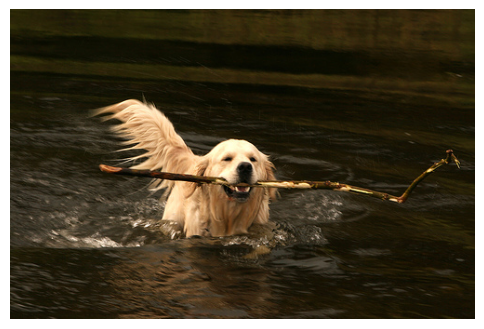

Greedy:      brown dog is jumping through the water with stick in his mouth
Beam search: brown dog is carrying stick in its mouth
Reference captions:
  - dog in water carrying long stick
  - dog picks up stick with his mouth while treading through water
  - large furry dog walking through the water with big stick in his mouth
  - the dog is holding branch swimming in the river
  - the dog retrieves the branch from the water

Example 2: 3215695965_69fbeba3d5.jpg


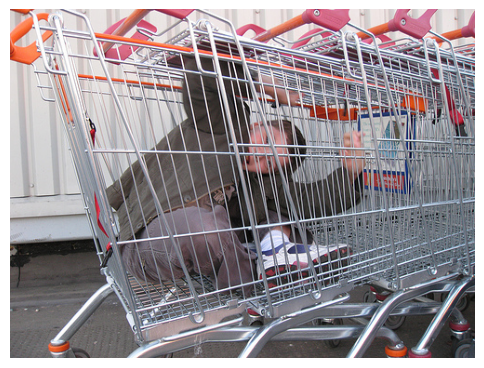

Greedy:      young boy is sitting in the paper <unk>
Beam search: little boy is sitting in the grass
Reference captions:
  - boy inside shopping cart
  - boy sits inside shopping cart
  - child plays inside shopping cart that has been stacked with others to create cage
  - young boy tapped in shopping cart
  - young boy trapped in shopping cart

Example 3: 537628742_146f2c24f8.jpg


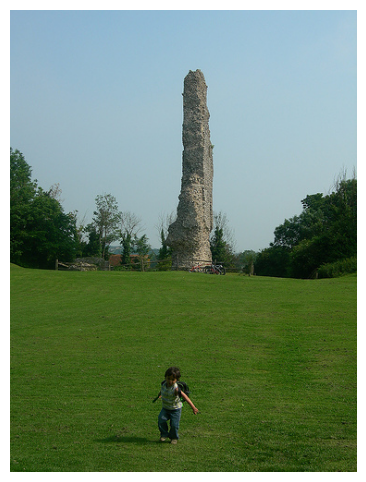

Greedy:      man in black shirt and black dog are standing in grassy field
Beam search: man in white shirt and black dog in grassy field
Reference captions:
  - little girl running in field
  - little girl walking on the green grass in front of big stone
  - small child is in grassy field near an old structure
  - small child running along the grass with large pilar in the background
  - young child walks on the grass away from stone monument

Example 4: 3461049169_e068ae4f25.jpg


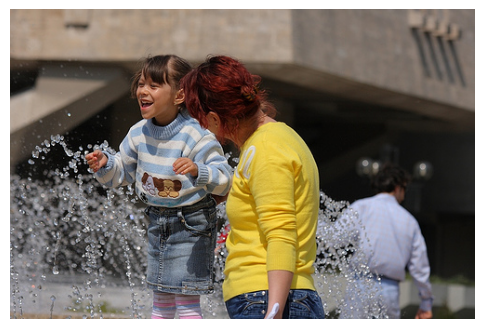

Greedy:      two young boys are playing in the water
Beam search: two young boys are playing in the water
Reference captions:
  - little girl and woman wearing yellow shirt get splashed by city fountain
  - mother and daughter at fountain
  - woman watches girl play in an urban fountain
  - young girl plays on the edge of fountain while an older woman watches
  - young girl standing in front of fountain with woman to her side

Example 5: 3050606344_af711c726c.jpg


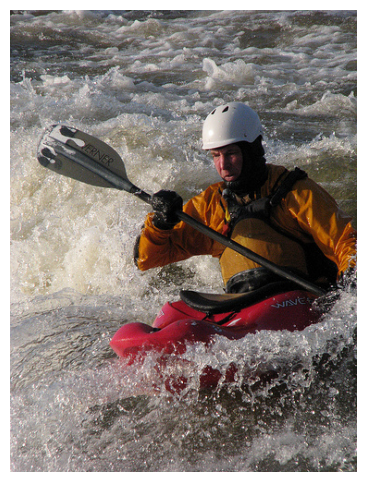

Greedy:      man in red kayak is kayaking in the water
Beam search: man kayaking in rough waters
Reference captions:
  - kayaker wearing yellow fights the rapids
  - man goes through whitewater in kayak
  - man is riding kayak through water
  - man kayaks in rough water
  - man kiyaking in rough water

Logged generated caption examples to W&B.


In [18]:
# Compare greedy and beam search on test examples, and log to W&B.
NUM_EXAMPLES = 5
BEAM_SIZE = 3

caption_examples_table = wandb.Table(
    columns=[
        "image",
        "image_name",
        "greedy_caption",
        "beam_caption",
        "reference_captions",
    ]
)

for i, image_name in enumerate(
    test_images[:NUM_EXAMPLES], start=1
):
    image_path = gc.IMAGE_DIR / image_name
    raw_image = Image.open(image_path).convert("RGB")
    model_image = cast(torch.Tensor, eval_transform(raw_image))

    greedy_caption = generate_caption_greedy(
        encoder=encoder,
        decoder=decoder,
        image=model_image,
        vocab=vocab,
        device=device,
        max_length=30,
    )

    beam_caption = generate_caption_beam_search(
        encoder=encoder,
        decoder=decoder,
        image=model_image,
        vocab=vocab,
        device=device,
        beam_size=BEAM_SIZE,
        max_length=30,
    )

    references = [
        clean_reference_caption(caption)
        for caption in image_to_captions[image_name]
    ]

    print("=" * 80)
    print(f"Example {i}: {image_name}")

    plt.figure(figsize=(6, 6))
    plt.imshow(raw_image)
    plt.axis("off")
    plt.show()

    print(f"Greedy:      {greedy_caption}")
    print(f"Beam search: {beam_caption}")
    print("Reference captions:")
    for ref in references:
        print(f"  - {ref}")
    print()

    caption_examples_table.add_data(
        wandb.Image(str(image_path)),
        image_name,
        greedy_caption,
        beam_caption,
        " | ".join(references),
    )

wandb.log({"examples/generated_captions": caption_examples_table})
print("Logged generated caption examples to W&B.")

## Quantitative evaluation with BLEU

BLEU evaluates n-gram overlap between generated and reference captions.

In [19]:
# Evaluate both greedy and beam search decoding.
greedy_bleu = evaluate_bleu(
    encoder=encoder,
    decoder=decoder,
    image_names=test_images,
    image_to_captions=image_to_captions,
    vocab=vocab,
    device=device,
    image_dir=gc.IMAGE_DIR,
    eval_transform=eval_transform,
    decoding_method="greedy",
    max_length=30,
)

beam_bleu = evaluate_bleu(
    encoder=encoder,
    decoder=decoder,
    image_names=test_images,
    image_to_captions=image_to_captions,
    vocab=vocab,
    device=device,
    image_dir=gc.IMAGE_DIR,
    eval_transform=eval_transform,
    decoding_method="beam",
    beam_size=3,
    max_length=30,
)

bleu_results = pd.DataFrame([
    {"decoding": "greedy", **greedy_bleu},
    {"decoding": "beam_size_3", **beam_bleu},
])

bleu_results

Evaluating BLEU with beam decoding: 100%|██████████| 810/810 [00:18<00:00, 42.78it/s]


,decoding,BLEU-1,BLEU-2,BLEU-3,BLEU-4
0,greedy,0.544902,0.357082,0.223555,0.133148
1,beam_size_3,0.572954,0.390243,0.255848,0.160904


In [20]:
wandb.log({
    "test/greedy_BLEU_1": greedy_bleu["BLEU-1"],
    "test/greedy_BLEU_2": greedy_bleu["BLEU-2"],
    "test/greedy_BLEU_3": greedy_bleu["BLEU-3"],
    "test/greedy_BLEU_4": greedy_bleu["BLEU-4"],
    "test/beam_BLEU_1": beam_bleu["BLEU-1"],
    "test/beam_BLEU_2": beam_bleu["BLEU-2"],
    "test/beam_BLEU_3": beam_bleu["BLEU-3"],
    "test/beam_BLEU_4": beam_bleu["BLEU-4"],
})

wandb.summary["best_val_loss"] = checkpoint["best_val_loss"]
wandb.summary["best_checkpoint_epoch"] = checkpoint["epoch"]
wandb.summary["best_checkpoint_path"] = str(BEST_CHECKPOINT_PATH)

In [21]:
artifact = wandb.Artifact(
    name=f"{RUN_NAME}_best_checkpoint",
    type="model",
    description=(
        "Best ResNet50 attention captioning checkpoint "
        "selected by validation loss."
    ),
)

artifact.add_file(str(RUN_DIR / "checkpoint_best.pth"))
artifact.add_file(str(RUN_DIR / "training_history.csv"))

with artifact.new_file("vocab.pkl", mode="wb") as f:
    pickle.dump(vocab, f)

wandb.log_artifact(artifact)
print("Logged model artifact to W&B.")

Logged model artifact to W&B.


In [22]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/val_loss,█▅▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇█
test/beam_BLEU_1,▁
test/beam_BLEU_2,▁
test/beam_BLEU_3,▁
test/beam_BLEU_4,▁
test/greedy_BLEU_1,▁
test/greedy_BLEU_2,▁
test/greedy_BLEU_3,▁
test/greedy_BLEU_4,▁
+5,...
